## Imports

In [1]:
!pip install -r requirements.txt -q
!pip install torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 --index-url https://download.pytorch.org/whl/cu118
!pip install accelerate -U

Looking in indexes: https://download.pytorch.org/whl/cu118


In [2]:
%pip install torch_geometric

Note: you may need to restart the kernel to use updated packages.


## Brain Graph Super-Resolution with SGC (Baseline)
This section implements a Simple Graph Convolution baseline for LR to HR graph prediction using 3-fold cross validation.

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon
import networkx as nx
import matplotlib.pyplot as plt

from MatrixVectorizer import MatrixVectorizer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DATA_DIR = "data"
TRAIN_LR_PATH = os.path.join(DATA_DIR, "lr_train.csv")
TRAIN_HR_PATH = os.path.join(DATA_DIR, "hr_train.csv")

EPOCHS = 200
LR = 1e-3
BATCH_SIZE = 16
K_PROP = 2
HIDDEN_DIM = 128
MLP_DIM = 256
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
def sanitize_vectors(x: np.ndarray) -> np.ndarray:
    # Ensure non-negative and finite values.
    x = np.nan_to_num(x)
    x[x < 0] = 0
    return x


def load_train_data(lr_path: str, hr_path: str):
    lr_vecs = np.loadtxt(lr_path, delimiter=",")
    hr_vecs = np.loadtxt(hr_path, delimiter=",")
    lr_vecs = sanitize_vectors(lr_vecs)
    hr_vecs = sanitize_vectors(hr_vecs)
    return lr_vecs, hr_vecs


def vectors_to_matrices(vectors: np.ndarray, matrix_size: int) -> np.ndarray:
    mats = [MatrixVectorizer.anti_vectorize(v, matrix_size) for v in vectors]
    return np.stack(mats, axis=0)


def normalize_adj_batch(adj: torch.Tensor) -> torch.Tensor:
    b, n, _ = adj.shape
    eye = torch.eye(n, device=adj.device).unsqueeze(0).expand(b, -1, -1)
    adj = adj + eye
    degree = adj.sum(dim=2)
    d_inv_sqrt = degree.pow(-0.5)
    d_inv_sqrt[d_inv_sqrt == float("inf")] = 0.0
    adj_norm = adj * d_inv_sqrt.unsqueeze(2) * d_inv_sqrt.unsqueeze(1)
    return adj_norm

In [5]:
class SGCBaseline(nn.Module):
    def __init__(self, lr_nodes=160, k_prop=2, hidden_dim=128, mlp_dim=256, out_dim=35778):
        super().__init__()
        self.lr_nodes = lr_nodes
        self.k_prop = k_prop
        self.node_proj = nn.Linear(lr_nodes, hidden_dim)
        self.mlp = nn.Sequential(
            nn.Linear(lr_nodes * hidden_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, out_dim),
        )

    def forward(self, adj_lr: torch.Tensor) -> torch.Tensor:
        adj_norm = normalize_adj_batch(adj_lr)
        # SGC propagation: X' = (A_norm)^K X
        x = adj_lr
        for _ in range(self.k_prop):
            x = torch.bmm(adj_norm, x)
        h = self.node_proj(x)
        h_flat = h.reshape(h.size(0), -1)
        out = self.mlp(h_flat)
        return out

In [6]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    running = 0.0
    for adj_lr, hr_vec in loader:
        adj_lr = adj_lr.to(DEVICE)
        hr_vec = hr_vec.to(DEVICE)

        optimizer.zero_grad()
        pred = model(adj_lr)
        loss = loss_fn(pred, hr_vec)
        loss.backward()
        optimizer.step()

        running += loss.item() * adj_lr.size(0)
    return running / len(loader.dataset)


def predict(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for adj_lr, _ in loader:
            adj_lr = adj_lr.to(DEVICE)
            pred = model(adj_lr).cpu().numpy()
            pred[pred < 0] = 0
            preds.append(pred)
    return np.concatenate(preds, axis=0)


def compute_metrics(pred_vecs: np.ndarray, gt_vecs: np.ndarray):
    pred_vecs = sanitize_vectors(pred_vecs)
    gt_vecs = sanitize_vectors(gt_vecs)

    mae = mean_absolute_error(gt_vecs.flatten(), pred_vecs.flatten())

    p = pred_vecs.flatten()
    q = gt_vecs.flatten()
    p_sum = p.sum()
    q_sum = q.sum()
    if p_sum == 0:
        p_sum = 1.0
    if q_sum == 0:
        q_sum = 1.0
    p = p / p_sum
    q = q / q_sum
    pcc = pearsonr(pred_vecs.flatten(), gt_vecs.flatten())[0]
    jsd = jensenshannon(p, q)

    mae_pc = []
    mae_ec = []
    mae_bc = []

    for i in range(pred_vecs.shape[0]):
        pred_mat = MatrixVectorizer.anti_vectorize(pred_vecs[i], 268)
        gt_mat = MatrixVectorizer.anti_vectorize(gt_vecs[i], 268)

        pred_graph = nx.from_numpy_array(pred_mat, edge_attr="weight")
        gt_graph = nx.from_numpy_array(gt_mat, edge_attr="weight")

        pred_pc = nx.pagerank(pred_graph, weight="weight")
        pred_ec = nx.eigenvector_centrality(pred_graph, weight="weight", max_iter=1000)
        pred_bc = nx.betweenness_centrality(pred_graph, weight="weight")

        gt_pc = nx.pagerank(gt_graph, weight="weight")
        gt_ec = nx.eigenvector_centrality(gt_graph, weight="weight", max_iter=1000)
        gt_bc = nx.betweenness_centrality(gt_graph, weight="weight")

        mae_pc.append(mean_absolute_error(list(pred_pc.values()), list(gt_pc.values())))
        mae_ec.append(mean_absolute_error(list(pred_ec.values()), list(gt_ec.values())))
        mae_bc.append(mean_absolute_error(list(pred_bc.values()), list(gt_bc.values())))

    return {
        "MAE": mae,
        "PCC": pcc,
        "JSD": jsd,
        "MAE(PC)": float(np.mean(mae_pc)),
        "MAE(EC)": float(np.mean(mae_ec)),
        "MAE(BC)": float(np.mean(mae_bc)),
    }


def save_predictions_csv(pred_vecs: np.ndarray, out_path: str):
    # Kaggle-style submission format.
    flat = pred_vecs.flatten()
    ids = np.arange(1, len(flat) + 1)
    data = np.column_stack([ids, flat])
    header = "ID,Predicted"
    np.savetxt(out_path, data, delimiter=",", header=header, comments="")

LR vectors: (168, 12720)
HR vectors: (168, 35778)
LR matrices: (168, 160, 160)

=== Fold 1/3 ===
Epoch 020 | Train MAE: 159.918461
Epoch 040 | Train MAE: 159.882884
Epoch 060 | Train MAE: 159.865813
Epoch 080 | Train MAE: 159.858392
Epoch 100 | Train MAE: 159.855533
Epoch 120 | Train MAE: 159.854657
Epoch 140 | Train MAE: 159.854450
Epoch 160 | Train MAE: 159.854430
Epoch 180 | Train MAE: 159.854430
Epoch 200 | Train MAE: 159.854429
Fold metrics:
  MAE: 0.137981
  PCC: 0.609137
  JSD: 0.296871
  MAE(PC): 0.000581
  MAE(EC): 0.013662
  MAE(BC): 0.023279

=== Fold 2/3 ===
Epoch 020 | Train MAE: 0.195928
Epoch 040 | Train MAE: 0.162135
Epoch 060 | Train MAE: 0.146134
Epoch 080 | Train MAE: 0.139265
Epoch 100 | Train MAE: 0.136674
Epoch 120 | Train MAE: 0.135885
Epoch 140 | Train MAE: 0.135716
Epoch 160 | Train MAE: 0.135699
Epoch 180 | Train MAE: 0.135696
Epoch 200 | Train MAE: 0.135696
Fold metrics:
  MAE: 319.575470
  PCC: -0.008113
  JSD: 0.806561
  MAE(PC): 0.000590
  MAE(EC): 0.01383

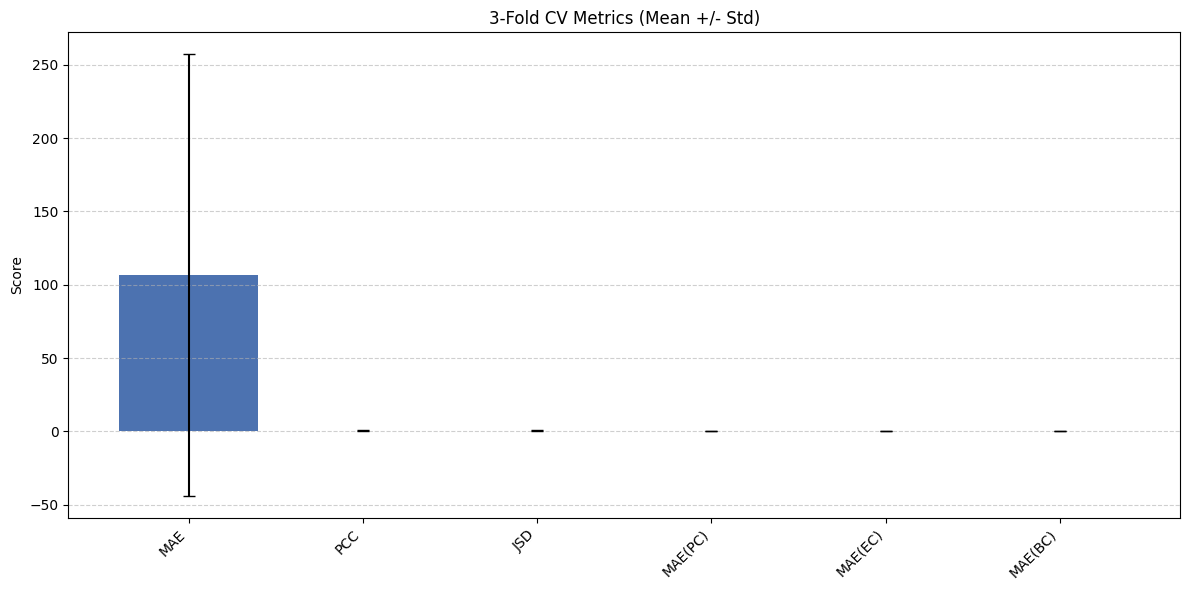

In [7]:
lr_vecs, hr_vecs = load_train_data(TRAIN_LR_PATH, TRAIN_HR_PATH)

lr_mats = vectors_to_matrices(lr_vecs, 160).astype(np.float32)
hr_vecs = hr_vecs.astype(np.float32)

print("LR vectors:", lr_vecs.shape)
print("HR vectors:", hr_vecs.shape)
print("LR matrices:", lr_mats.shape)

kfold = KFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
all_fold_metrics = []

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(lr_mats), start=1):
    print(f"\n=== Fold {fold_idx}/3 ===")

    train_adj = torch.from_numpy(lr_mats[train_idx])
    train_hr = torch.from_numpy(hr_vecs[train_idx])
    val_adj = torch.from_numpy(lr_mats[val_idx])
    val_hr = torch.from_numpy(hr_vecs[val_idx])

    train_loader = DataLoader(
        TensorDataset(train_adj, train_hr),
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )
    val_loader = DataLoader(
        TensorDataset(val_adj, val_hr),
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
    )

    model = SGCBaseline(
        lr_nodes=160,
        k_prop=K_PROP,
        hidden_dim=HIDDEN_DIM,
        mlp_dim=MLP_DIM,
        out_dim=hr_vecs.shape[1],
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.L1Loss()

    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, train_loader, optimizer, loss_fn)
        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Train MAE: {loss:.6f}")

    preds = predict(model, val_loader)

    # Save fold predictions for submission.
    fold_csv = os.path.join(OUTPUT_DIR, f"predictions_fold_{fold_idx}.csv")
    save_predictions_csv(preds, fold_csv)

    metrics = compute_metrics(preds, hr_vecs[val_idx])
    all_fold_metrics.append(metrics)

    print("Fold metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")

metric_names = list(all_fold_metrics[0].keys())
means = [np.mean([m[n] for m in all_fold_metrics]) for n in metric_names]
stds = [np.std([m[n] for m in all_fold_metrics]) for n in metric_names]

plt.figure(figsize=(12, 6))
plt.bar(metric_names, means, yerr=stds, capsize=4, color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.title("3-Fold CV Metrics (Mean +/- Std)")
plt.ylabel("Score")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()